# 20 · P2 Data Understanding — 7개년(2019~2025) 통합 EDA 6패널

> CRISP-DM **P2(Data Understanding)** 시각화. 노트북 11이 빌드한 **하모나이즈 패널(90,996행)** 을 입력으로,
> `src/eda_overview.py`(SSOT)의 **6개 패널 함수**를 호출해 표본 구조·인구통계·신뢰 시계열·가용성·상관·P4 연결을
> 단계별로 재현한다. 각 패널 앞에 *중간 산출(표)* 로 "왜 이렇게 보는가"를 먼저 보인 뒤 패널 figure를 임베드한다.
>
> **thin 원칙**: 가중 집계·작도 로직은 `src/eda_overview.py`가 정본. 본 노트북은 그 **단계함수**
> (`wmean_by_year`·`wcomp_by_year`·`panel1~6`)를 호출할 뿐 로직을 재구현하지 않는다.
>
> - 입력: `data/processed/audience_harmonized.parquet`(**gitignore** → `python src/harmonize.py` 또는 노트북 11로 재생성).
> - 산출: `docs/design/figures/eda_p1~p6_*.png`(패널 함수가 저장) → 본 노트북에 인라인 임베드.
>
> ⚠️ **검증 게이트**([data-spec.md](../docs/design/data-spec.md) §6): 아래 수치는 **데이터 이해용 탐색 시각화**이며
> KPF 원자료 재검증 전 보고서·웹데모 직접 인용 신중(방향·구조 해석 위주).

**종합 문서**: [eda-overview.md](../docs/design/eda-overview.md) · [analysis-master-plan.md](../docs/design/analysis-master-plan.md) §3 · 교차참조 P4: [alignment-trust-trend.md](../docs/design/alignment-trust-trend.md) · [trend-apc-results.md](../docs/design/trend-apc-results.md)

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

# ROOT 탐색 후 src를 path에 추가 → 단계함수 import(로직 재구현 금지)
ROOT = Path.cwd()
while not (ROOT / "src" / "eda_overview.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

get_ipython().run_line_magic("matplotlib", "inline")  # 인라인 렌더(Agg 미사용 정책)
import matplotlib.pyplot as plt
from matplotlib import font_manager
def _kfont():
    for nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
        try:
            font_manager.findfont(nm, fallback_to_default=False)
            plt.rcParams["font.family"] = nm; break
        except Exception: continue
    plt.rcParams["axes.unicode_minus"] = False
_kfont()  # eo.panel* 호출 전에 전역 rcParams로 한글 폰트 고정

import eda_overview as eo            # 6패널 SSOT
from IPython.display import Image, display

df = pd.read_parquet(eo.PARQUET)
assert len(df) == 90996, f"행수 불일치: {len(df):,}"
print("ROOT =", ROOT)
print(f"패널 로드: {len(df):,}행 × {df.shape[1]}컬럼 | 연도 = {eo.YEARS}")

ROOT = C:\Users\kik32\workspace\Dacon\Media-Statistics-Analysis-and-Utilization-Competition
패널 로드: 90,996행 × 32컬럼 | 연도 = [2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. 표본 구조 — 2022 표본지배와 가중치 균등화

먼저 **왜 가중치가 필요한가**를 수치로 본다. 연도별 N과 원가중(`wt`)·연도균등(`wt_year_eq`) 가중합을
대조하면, 2022 개인용 대표본(N=58,936)이 통합 패널을 지배함과 `wt_year_eq`가 이를 균등화함이 드러난다.

In [2]:
# 중간 산출: 연도별 N · 원가중/연도균등 가중합 · 2022 기여 비중
n_by_year = df.groupby("year").size().reindex(eo.YEARS)
wsum = df.groupby("year")[["wt", eo.WCOL]].sum().reindex(eo.YEARS).round(1)
tbl = pd.DataFrame({"N": n_by_year, "wt합": wsum["wt"], "wt_year_eq합": wsum[eo.WCOL]})
tbl["N비중%"] = (n_by_year / len(df) * 100).round(1)
print(f"총 N = {len(df):,} | 균등목표 N/T = {len(df)/len(eo.YEARS):,.1f}")
print(f"2022 원가중 기여비중 = {wsum['wt'][2022]/wsum['wt'].sum():.1%}")
tbl

총 N = 90,996 | 균등목표 N/T = 12,999.4
2022 원가중 기여비중 = 64.8%


,N,wt합,wt_year_eq합,N비중%
year,,,,
2019,5040,5039.2,12999.4,5.5
2020,5010,5010.0,12999.4,5.5
2021,5010,5010.0,12999.4,5.5
2022,58936,58936.0,12999.4,64.8
2023,5000,5000.0,12999.4,5.5
2024,6000,6000.0,12999.4,6.6
2025,6000,6000.0,12999.4,6.6


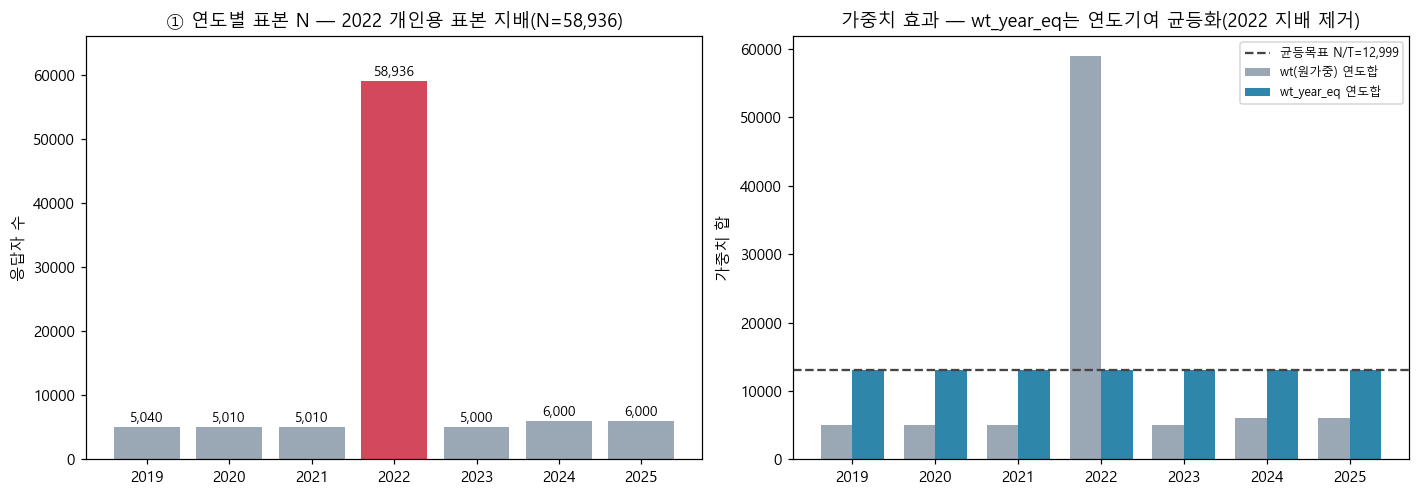

In [3]:
# 패널 ① — 함수 호출(작도는 src) 후 PNG 인라인 임베드
display(Image(filename=str(eo.panel1_sample_structure(df))))

**관찰**: 2022가 N의 **64.8%**(원가중 기여도 동일 규모)를 차지해 비가중·원가중 추세를 지배한다.
`wt_year_eq`는 각 연도 가중합을 **N/T≈12,999.4로 균등화** → 2022 지배를 제거한다. 이후 모든 추세·평균은 이 가중치를 쓴다.

## 2. 인구통계 구성 — 2022 전후 구조 안정성

2022는 표본설계·분석단위가 달라도(개인용·대표본) **인구 구성 자체는 타 연도와 정합**한가? 학력 구성비(가중)를
연도별로 보면 2022 전후 급단절 없이 완만한 추세(중졸이하↓·대재이상↑)만 보인다 → 통합 패널의 외적 타당성 방증.

In [4]:
# 중간 산출: 학력 구성비(가중 %) 연도 추이 — 2022 전후 연속성 확인
edu_comp = (eo.wcomp_by_year(df, "edu") * 100).round(1)
edu_comp.columns = [eo.EDU_LBL.get(c, c) for c in edu_comp.columns]
edu_comp

,중졸이하,고졸,대재이상,대학원
2019,16.6,40.2,42.3,0.9
2020,12.6,41.4,45.5,0.5
2021,15.4,39.5,44.3,0.8
2022,13.0,37.7,48.9,0.5
2023,8.5,43.4,47.6,0.5
2024,10.5,37.1,52.0,0.4
2025,10.3,38.4,51.0,0.4


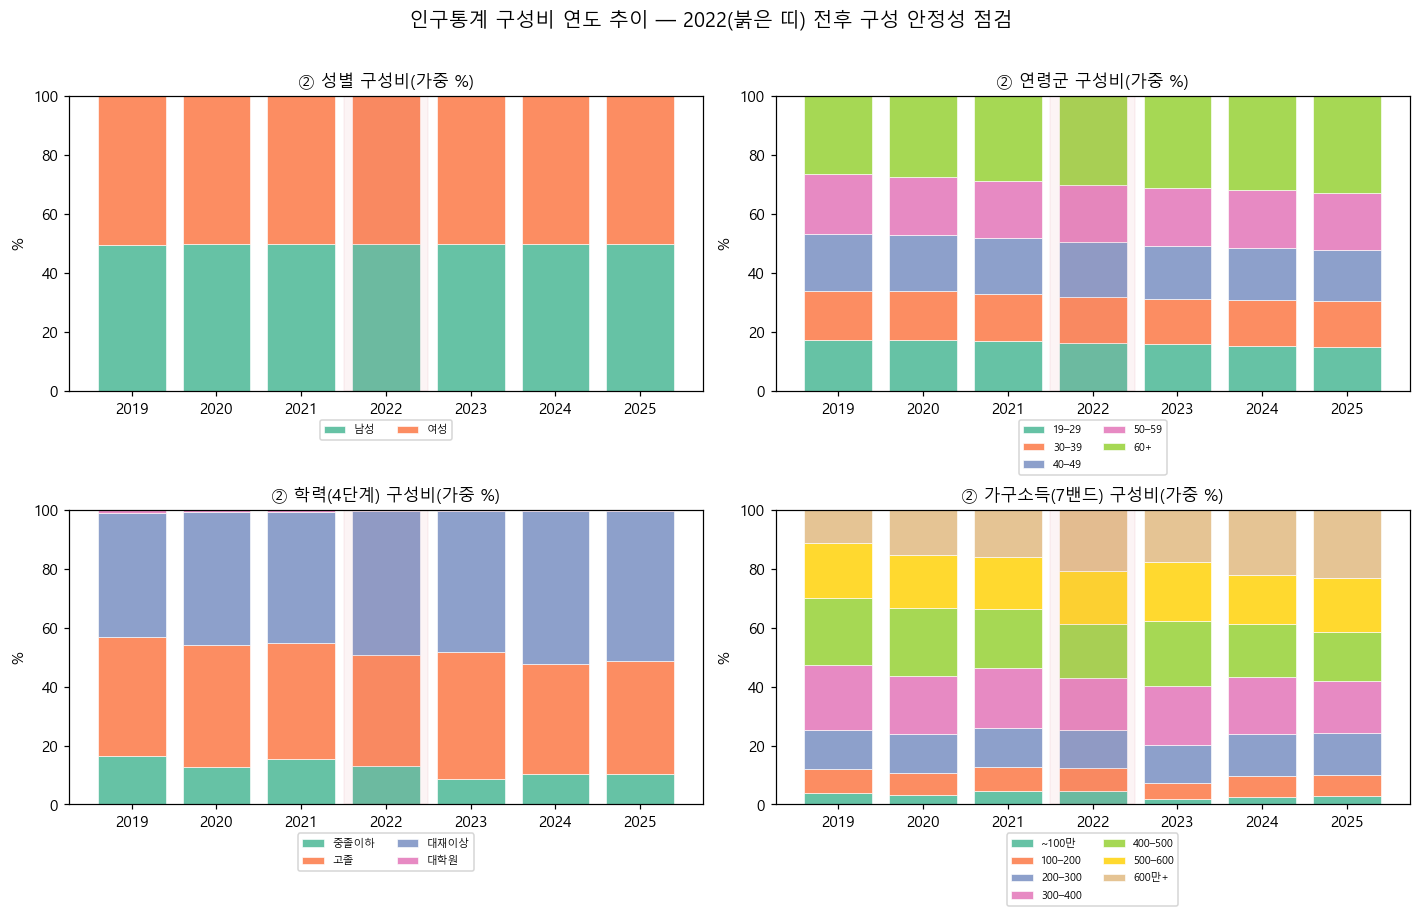

In [5]:
display(Image(filename=str(eo.panel2_demographics(df))))

**관찰**: 성·연령군·학력·소득 구성비가 2022(붉은 띠) 전후로 연속적이다. 학력 상향·고령화 등 완만한 추세는
모집단 변화와 일치 → 2022 대표본이 구성 측면에서 이질적 이상치가 아님을 시사.

## 3. 신뢰 시계열 — 단일문항 부재 vs credibility 배터리 (⚠️ 재검증 전 인용 신중)

핵심 질문: 추세를 그릴 토대가 되는 지표는 무엇인가? 단일 신뢰문항은 **구조적 부재**(2019 등)로 시계열이 짧지만,
credibility 핵심3지표는 7개년 전부 가용하다. 합성 `cred_mean`(3지표) 가중평균의 **비단조 궤적**이 P4 정렬추세의 토대다.

In [6]:
# 중간 산출: cred_mean(핵심3지표 평균) 가중평균 추세 + 단일문항 가용연도
df_cm = df.assign(cred_mean=df[eo.CRED_CORE3].mean(axis=1))
cm = eo.wmean_by_year(df_cm, "cred_mean").round(3)
print("cred_mean 가중평균 추세:", [cm[y] for y in eo.YEARS])
avail = {c: [y for y in eo.YEARS if df[df.year == y][c].notna().sum() > 0] for c in eo.TRUST_SINGLE}
for c, ys in avail.items():
    print(f"  {c} 가용연도: {ys}")
cm.to_frame("cred_mean 가중평균")

cred_mean 가중평균 추세: [np.float64(3.034), np.float64(3.249), np.float64(3.305), np.float64(3.211), np.float64(3.19), np.float64(3.176), np.float64(3.39)]
  trust_news_overall 가용연도: [2020, 2021, 2022, 2023, 2024, 2025]
  trust_news_used 가용연도: [2021, 2022, 2023, 2024, 2025]
  trust_society 가용연도: [2020, 2021, 2022, 2023, 2024, 2025]


,cred_mean 가중평균
2019,3.034
2020,3.249
2021,3.305
2022,3.211
2023,3.190
2024,3.176
2025,3.390


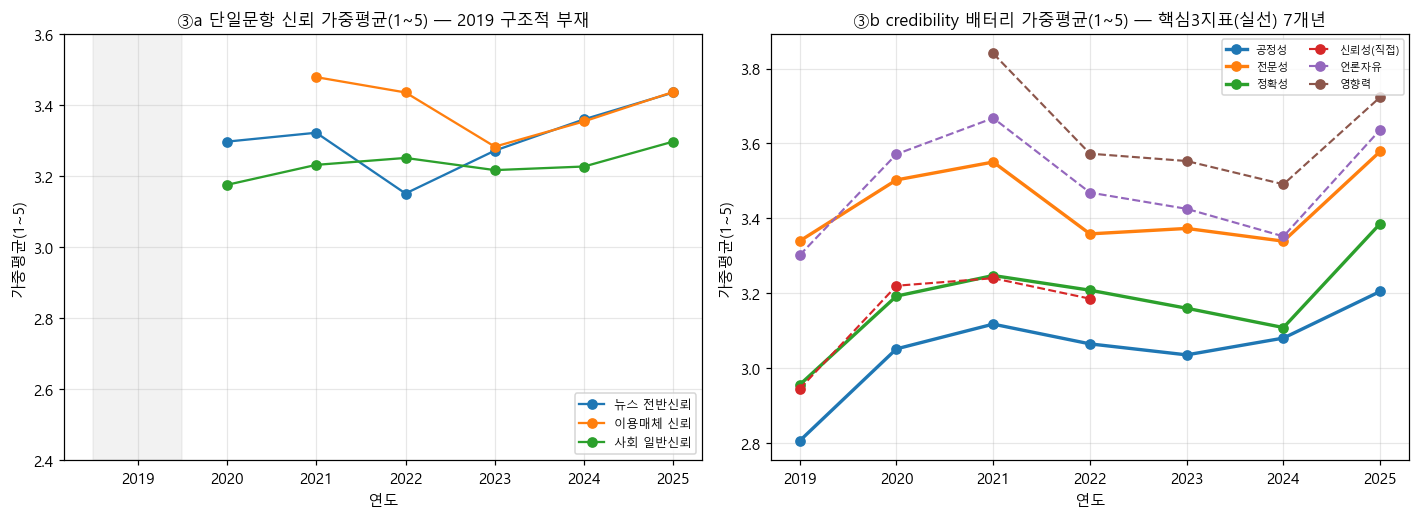

In [7]:
display(Image(filename=str(eo.panel3_trust_timeseries(df))))

**관찰**: `cred_mean` 가중평균은 **3.034→3.249→3.305→3.211→3.190→3.176→3.390** —
2019→2020 상승 후 고원, 2024 저점→2025 반등의 **비단조 패턴**. 이는 P4 정렬 잠재평균(§6)과 변곡점까지 동일하다.
단일문항 `trust_news_overall`은 2019 부재·다소 다른 궤적(문항 성격 차)이라 추세 본진은 배터리로 본다.

## 4. 지표 가용성 — 결측은 '무응답'이 아니라 '구조적 부재'

연도×변수 non-NA 비율을 보면 결측이 무작위 무응답이 아니라 **문항 도입/폐지**에서 비롯된 구조적 부재임이 드러난다.
이는 측정 동등성 검정에서 어떤 연도·지표를 비교 가능한지 결정한다.

In [8]:
# 중간 산출: 신뢰 관련 변수 non-NA 비율(연도×변수) — 구조적 결측 패턴
cols = eo.TRUST_SINGLE + eo.CRED6
nonna = pd.DataFrame(
    {c: [round(df[df.year == y][c].notna().mean(), 2) for y in eo.YEARS] for c in cols},
    index=eo.YEARS).T
nonna

,2019,2020,2021,2022,2023,2024,2025
trust_news_overall,0.0,1.0,1.0,1.0,1.0,1.0,1.0
trust_news_used,0.0,0.0,1.0,1.0,1.0,1.0,1.0
trust_society,0.0,1.0,1.0,1.0,1.0,1.0,1.0
cred_fair,1.0,1.0,1.0,1.0,1.0,1.0,1.0
cred_professional,1.0,1.0,1.0,1.0,1.0,1.0,1.0
cred_accurate,1.0,1.0,1.0,1.0,1.0,1.0,1.0
cred_trustworthy,1.0,1.0,1.0,1.0,0.0,0.0,0.0
press_free,1.0,1.0,1.0,1.0,1.0,1.0,1.0
media_influence,0.0,0.0,1.0,1.0,1.0,1.0,1.0


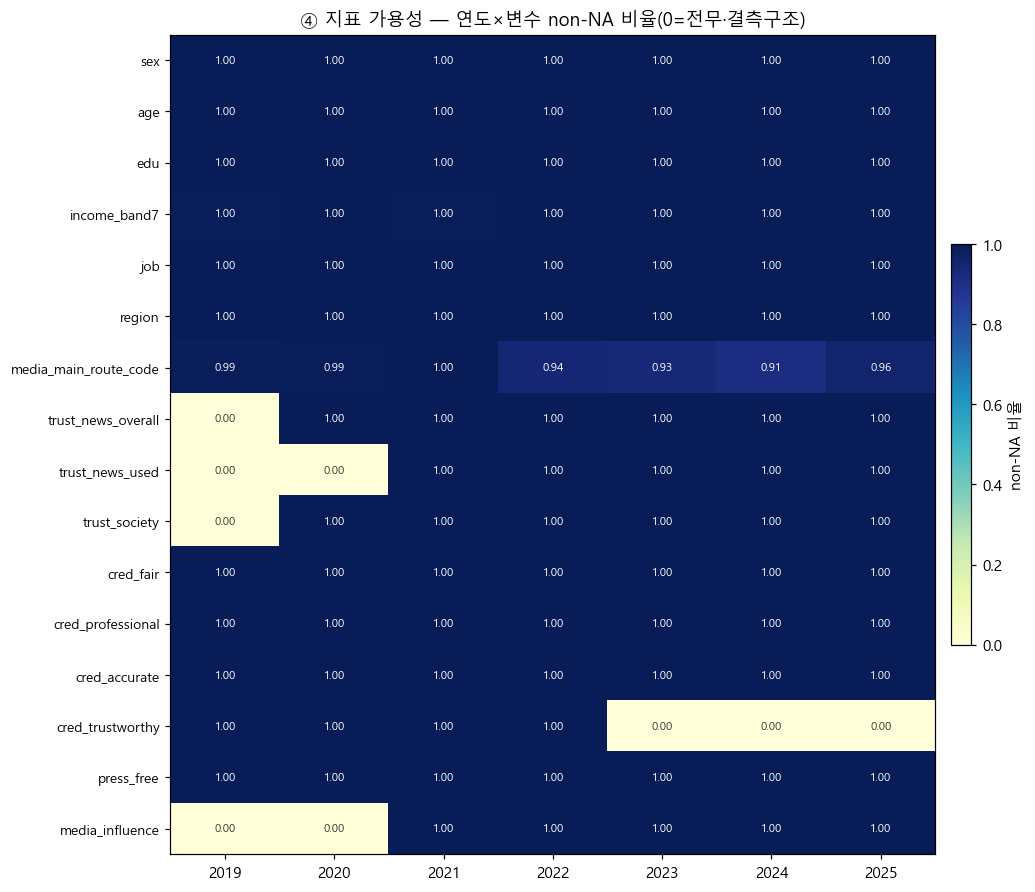

In [9]:
display(Image(filename=str(eo.panel4_availability(df))))

**관찰**: 인구·핵심3지표·`press_free`는 7개년 ≈1.00. 반면 `trust_news_overall`(2019=0)·`trust_news_used`
(2019·2020=0)·`cred_trustworthy`(2023~25=0)·`media_influence`(2019·2020=0)는 0=문항 부재. → MGCFA는 7개년 공통 핵심3지표를 입력으로 쓴다.

## 5. 상관/분포 — 단일요인 타당성과 인구통계 구배

핵심3지표가 **하나의 잠재요인(credibility)** 으로 묶이는가? 완전케이스 상관이 중간~높은 양수면 단일요인 구성이 타당하다(MGCFA 근거).
또 가중 `cred_mean`의 학력·연령 구배는 회귀·세그먼트(P4-4)의 사전 가설이 된다.

In [10]:
# 중간 산출: 핵심3지표 완전케이스 상관 + cred_mean 학력/연령 구배(가중)
cc = df[eo.CRED_CORE3].dropna()
corr = pd.DataFrame(np.corrcoef(cc.values.T),
                    index=[eo.CRED_LABEL[c] for c in eo.CRED_CORE3],
                    columns=[eo.CRED_LABEL[c] for c in eo.CRED_CORE3]).round(2)
print(f"완전케이스 N = {len(cc):,}")
print("학력별 cred_mean(가중):", {eo.EDU_LBL[e]: round(eo.wmean(df_cm[df_cm.edu == e], "cred_mean"), 2) for e in [1, 2, 3, 4]})
age_grp = pd.cut(df_cm["age"], bins=eo.AGE_BINS, labels=eo.AGE_LBL)
print("연령군 cred_mean(가중):", {g: round(eo.wmean(df_cm.assign(g=age_grp)[lambda d: d.g == g], "cred_mean"), 2) for g in eo.AGE_LBL})
corr

완전케이스 N = 90,996
학력별 cred_mean(가중): {'중졸이하': 3.3, '고졸': 3.24, '대재이상': 3.19, '대학원': 2.98}
연령군 cred_mean(가중): {'19–29': 3.19, '30–39': 3.18, '40–49': 3.19, '50–59': 3.2, '60+': 3.3}


,공정성,전문성,정확성
공정성,1.00,0.55,0.64
전문성,0.55,1.00,0.55
정확성,0.64,0.55,1.00


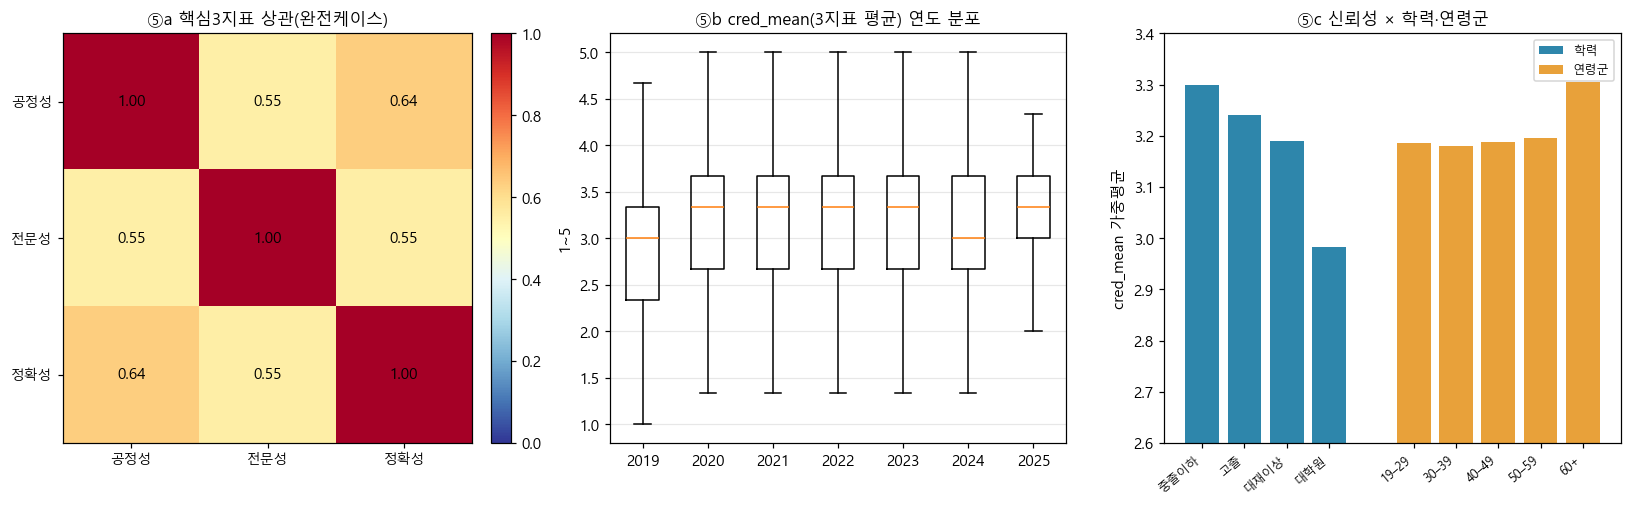

In [11]:
display(Image(filename=str(eo.panel5_corr_dist(df))))

**관찰**: 상관 공정–정확 **.64**, 공정–전문 **.55**, 전문–정확 **.55**(완전케이스 N=90,996) → 단일 잠재요인 구성 타당.
구배는 **학력 역구배**(중졸이하 3.30 > 대학원 2.98)·**연령 정구배**(60+ 3.30 최고) → 저학력·고령일수록 언론을 더 긍정 평가.

## 6. P4 연결 — '신뢰성 상승은 시대(기간) 효과'

P4 산출(정렬 잠재추세·APC 기간효과)을 **인용**해 EDA 추이와 삼각검증한다. 본 패널은 재계산이 아니라 `docs/design/*.md`의
확정 수치를 시각화한다(출처: `eo.P4_*` 상수).

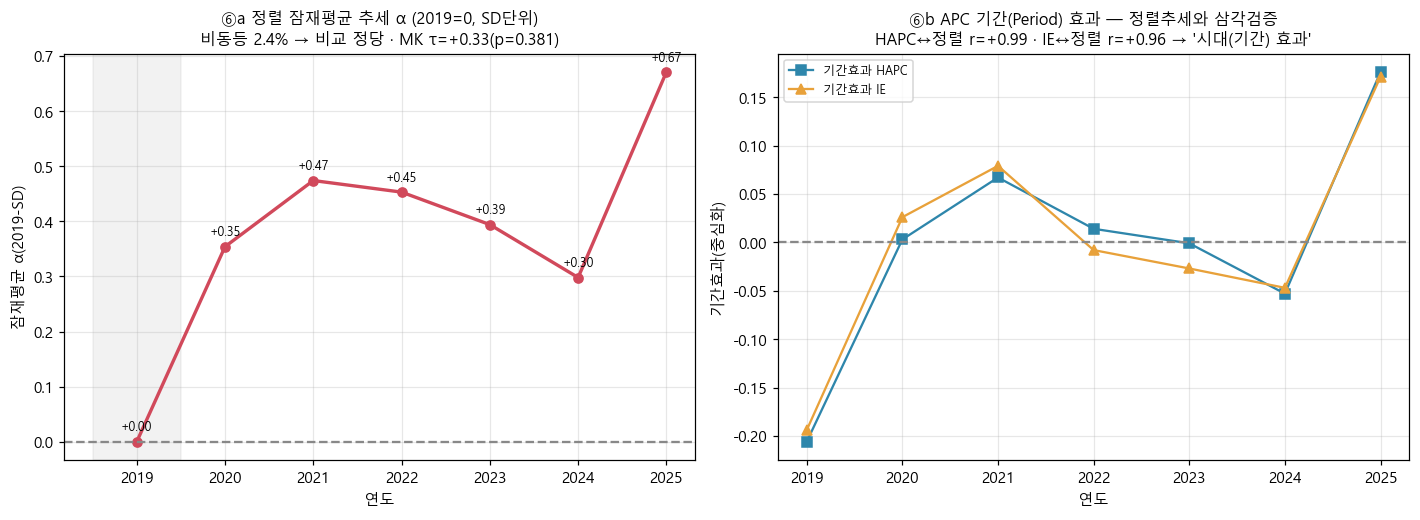

정렬 잠재평균 α(2019=0): {2019: 0.0, 2020: 0.354, 2021: 0.474, 2022: 0.453, 2023: 0.394, 2024: 0.298, 2025: 0.671}
비동등 비율 = 2.4% (≤20% → 비교 정당) | MK τ=+0.33, p=0.381


In [12]:
display(Image(filename=str(eo.panel6_p4_link())))
print("정렬 잠재평균 α(2019=0):", {y: eo.P4_ALIGN_ALPHA[y] for y in eo.YEARS})
print(f"비동등 비율 = {eo.P4_NONINVAR_PCT}% (≤20% → 비교 정당) | MK τ={eo.P4_MK_TAU:+.2f}, p={eo.P4_MK_P:.3f}")

**관찰**: 정렬 잠재평균은 2019→2020 +0.354 계단 후 고원, 2025 +0.671 고점. 비동등 2.4%로 비교가 정당하며,
APC 기간효과가 정렬추세와 r=+0.99/+0.96 → 상승의 주성분은 **기간(시대) 효과**. ⚠️ 2019 단일문항 부재 연도라 2019→2020 계단은 재검증 1순위.

## 7. 검증 셀 — `docs/design/eda-overview.md` 수치와 일치하는가 (입증)

노트북 출력이 종합 문서의 확정 수치와 일치함을 assert로 입증한다. 하나라도 어긋나면 실행이 실패한다.

In [13]:
# (a) 표본 구조
EXPECT_N = {2019: 5040, 2020: 5010, 2021: 5010, 2022: 58936, 2023: 5000, 2024: 6000, 2025: 6000}
for y in eo.YEARS:
    assert n_by_year[y] == EXPECT_N[y], (y, n_by_year[y])
assert n_by_year.sum() == 90996
assert round(wsum["wt"][2022] / wsum["wt"].sum() * 100, 1) == 64.8
assert round(len(df) / len(eo.YEARS), 1) == 12999.4

# (b) 신뢰 시계열 — cred_mean 가중평균(문서 §1.③)
EXPECT_CM = [3.034, 3.249, 3.305, 3.211, 3.190, 3.176, 3.390]
assert [cm[y] for y in eo.YEARS] == EXPECT_CM, [cm[y] for y in eo.YEARS]

# (c) 상관(문서 §1.⑤): 공정–정확 .64, 공정–전문 .55, 전문–정확 .55
assert round(corr.iloc[0, 2], 2) == 0.64 and round(corr.iloc[0, 1], 2) == 0.55 and round(corr.iloc[1, 2], 2) == 0.55

# (d) 인구통계 구배(문서 §1.⑤): 학력 역구배 끝점
edu_cm = {e: eo.wmean(df_cm[df_cm.edu == e], "cred_mean") for e in [1, 4]}
assert round(edu_cm[1], 2) == 3.30 and round(edu_cm[4], 2) == 2.98

# (e) P4 인용 상수(문서 §1.⑥)와 일치
assert eo.P4_NONINVAR_PCT == 2.4 and round(eo.P4_MK_TAU, 2) == 0.33 and eo.P4_ALIGN_ALPHA[2025] == 0.671

print("[검증 PASS] 표본구조·신뢰추세·상관·인구구배·P4 인용 — 문서 수치와 전부 일치")

[검증 PASS] 표본구조·신뢰추세·상관·인구구배·P4 인용 — 문서 수치와 전부 일치


## 8. `src/eda_overview.py` 코드리뷰 결론 & 다음 단계

**코드리뷰 — 통과**:
- **가중 정확성**: `wmean`/`wmean_by_year`/`wcomp_by_year`가 NA를 col·weight 양쪽에서 제거하고 `np.average(weights=)`로
  집계 → 추세·평균은 `wt_year_eq`(2022 지배 제거), 구성비도 동일 가중. 05 §6 가중 원칙과 일치.
- **결측 처리**: 가용성·상관은 구조적 부재(문항 도입/폐지)를 0/완전케이스로 가시화 — '무응답'과 '부재'를 혼동하지 않음.
- **상관(⑤a)은 완전케이스 Pearson**(비가중): 탐색용 단일요인 타당성 점검 목적으로 문서(`eda-overview.md` §1.⑤)와 정합 → 결함 아님.
- **P4 연결(⑥)은 재계산이 아니라 인용**(`P4_*` 상수, 출처 docs) — 책임 경계 명확.
- → **결함 없음. 강제 수정 없이 리뷰 통과**(과잉수정 금지 원칙).

**다음**: [`21-mgcfa-invariance.ipynb`](21-mgcfa-invariance.ipynb) — 핵심3지표 단일요인의 측정 동등성(configural→metric→scalar, ΔCFI/ΔRMSEA)을 `src/mgcfa_invariance.py`로 단계별 입증.